In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size="5" color="red">자연어처리 패키지</font>
1. 텍스트 전처리
2. 품사태깅
3. 어휘데이터 베이스 사용
4. 구조화된 문서의 빈도수, 분류분석, 연관분석, 감정분석 (단점) 속도가 느림

In [3]:
import nltk
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [4]:
# 말뭉치 리스트
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [6]:
# 말뭉치 데이터 셋 (소설 엠마내용)
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
emma[:40]

'[Emma by Jane Austen 1816]\n\nVOLUME I\n\nCH'

In [7]:
# emma 의 글자수, 문장수, 단어수
print(len(emma))

887071


In [10]:
from nltk.tokenize import sent_tokenize
sent_tokens = sent_tokenize(emma)
print(len(sent_tokens))
print(sent_tokens[5])

7456
Even before Miss Taylor had ceased to hold the nominal
office of governess, the mildness of her temper had hardly allowed
her to impose any restraint; and the shadow of authority being
now long passed away, they had been living together as friend and
friend very mutually attached, and Emma doing just what she liked;
highly esteeming Miss Taylor's judgment, but directed chiefly by
her own.


In [12]:
from nltk.tokenize import word_tokenize
print(word_tokenize(sent_tokens[0]))

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', '.']


In [32]:
# RegexpTokenizer() : 토큰화 할때 해당 졍규식에 해당하는 word 만 적용
from nltk.tokenize import RegexpTokenizer
digitRet = RegexpTokenizer('\d+')
alphaRet = RegexpTokenizer('\w+')
digits = digitRet.tokenize(sent_tokens[0])
print(digits)
words = alphaRet.tokenize(sent_tokens[0])
print(words)

['1816']
['Emma', 'by', 'Jane', 'Austen', '1816', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', 'and', 'had', 'lived', 'nearly', 'twenty', 'one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her']


## 2. 형태소 분석

In [23]:
words2 = ['sending', 'cooking', 'files', 'lives', 'crying']
from nltk.stem import PorterStemmer
pst = PorterStemmer()
pst.stem(words2[0])

'send'

In [24]:
[pst.stem(word) for word in words2]

['send', 'cook', 'file', 'live', 'cri']

In [25]:
# 어간추출 2
from nltk.stem import LancasterStemmer
lst = LancasterStemmer()
[lst.stem(word) for word in words2]

['send', 'cook', 'fil', 'liv', 'cry']

In [38]:
# 어간 추출(3) RegexpStemmer : 정규표현식에 해당하는 부분만 어간 추출
from nltk.stem import RegexpStemmer
rst = RegexpStemmer('ing')
[rst.stem(word) for word in words2]

['send', 'cook', 'files', 'lives', 'cry']

In [30]:
# 품사태깅
from nltk.tag import pos_tag
tagged_list = pos_tag(word_tokenize(sent_tokens[0]))
print(word_tokenize(sent_tokens[0]))
print('품사태깅한 결과 :', tagged_list)

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', '.']
품사태깅한 결과 : [('[', 'NNS'), ('Emma', 'NNP'), ('by', 'IN'), ('Jane', 'NNP'), ('Austen', 'NNP'), ('1816', 'CD'), (']', 'NNP'), ('VOLUME', 'NNP'), ('I', 'PRP'), ('CHAPTER', 'VBP'), ('I', 'PRP'), ('Emma', 'NNP'), ('Woodhouse', 'NNP'), (',', ','), ('handsome', 'NN'), (',', ','), ('clever', 'NN'), (',', ','), ('and', 'CC'), ('rich', 'JJ'), (',', ','), ('with', 'IN'), ('a', 'DT'), ('comfortable', 'JJ'), ('home', 'NN'), ('and', 'CC'), ('happy', 'JJ'), ('disposition', 'NN'), (',', ','), ('seemed', 'VBD'), ('to', 'TO'), ('unite', 'VB'),

## 퀴즈 : emma소설안에서
- 특수문자가 들어가지 않는 3글자 이상의 단어만 추출해서 품사태킹을 하시오. ex)[('emma','명'), ('was','동'),...]
- "Emma" 단어가 몇번 등장하며, 품사 태깅이 어떤 품사들로 되어 있는지 모두 출력하시오
- 내가 원하는 품사(명사)의 단어만 뽑아 등장하는 명사의 종류 갯수를 출력하시오

In [47]:
from nltk.tokenize import RegexpTokenizer
alphaRet = RegexpTokenizer('\w{3,}')
words = alphaRet.tokenize(emma)
tags = pos_tag(words)
len(words)
len(tags)

123877

In [40]:
from nltk.stem import LancasterStemmer
lst = LancasterStemmer()
len([lst.stem(words) for words in emma])

887071

In [42]:
print(len(set(words)))  # 3가지 이상 단어의 종류수

7630


In [49]:
print(words[:5])
print(tags[:5])

['Emma', 'Jane', 'Austen', '1816', 'VOLUME']
[('Emma', 'NNP'), ('Jane', 'NNP'), ('Austen', 'NNP'), ('1816', 'CD'), ('VOLUME', 'NNP')]


In [85]:
pos=[]
for tag in tags:
    if tag[0] == 'Emma':
        pos.append(tag[1])
pos = [tag for tag in tags if tag[0] == 'Emma']
#print('Emma 출현횟수 :', len(pos))
#print('Emma의 품사 :', set(pos))
pos

[('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'VBP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'JJ'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', 'NNP'),
 ('Emma', '

In [62]:
result=[]
if tag in tags:
    result.append(tag)    # 다할려면 tags
print(result)

[('FINIS', 'NNP')]


In [73]:
results=[]
for tag in tags:
    if tag == 'NNP':  # 'Emma'와 일치하면
        results.append(tags)  # 들여쓰기를 적용하여 'Emma'를 추가

print(results)  # ['Emma', 'Emma']

[]


In [80]:
post_cnt = dict()
for word, tag in tags:
    if word == 'Emma':
        if tag in post_cnt:
            post_cnt[tag]+=1
        else:
            post_cnt[tag]=0
post_cnt

{'NNP': 837,
 'VBP': 3,
 'JJ': 3,
 'VB': 4,
 'NNS': 1,
 'RB': 0,
 'NN': 6,
 'NNPS': 1,
 'VBN': 0,
 'VBD': 0}

In [94]:
#3번
nouns_list = [] # 명사들만
for word, tag in tags:
    if (tag == 'NN') | (tag =='NNS'):
        nouns_list.append(word)


nouns_list = [word for word, tag in tags if (tag == 'NN') | (tag =='NNS')]
print(len(nouns_list))

22147


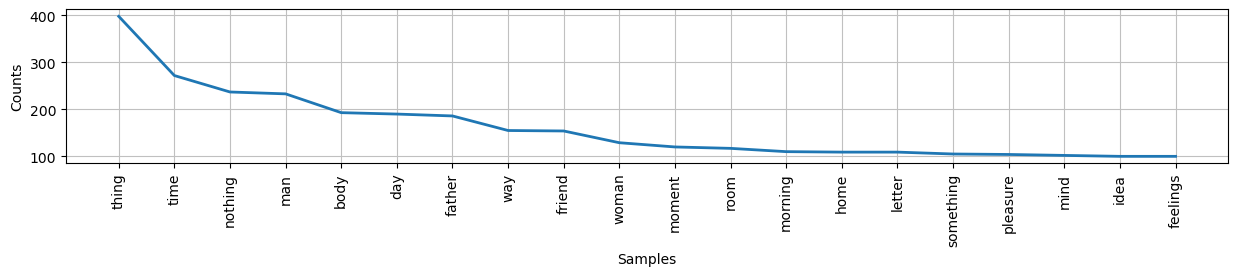

In [96]:
# 최빈 단어 시각화
import matplotlib.pyplot as plt
from nltk import Text
emma_text = Text(nouns_list)
plt.figure(figsize=(15,2))
emma_text.plot(20)
plt.show()

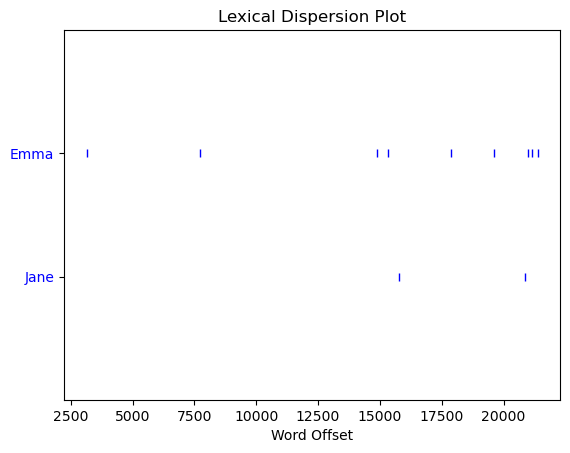

In [97]:
emma_text.dispersion_plot(['Emma','Jane'])

In [99]:
# 고유명사
name_list = [word for word, tag in tags if (tag == 'NNP') | (tag =='NNPS')]
len(set(name_list))

654

In [100]:
from nltk import FreqDist
FreqDist(name_list)      

FreqDist({'Emma': 840, 'Mrs': 696, 'Miss': 569, 'Harriet': 484, 'Weston': 433, 'Knightley': 389, 'Elton': 382, 'Jane': 295, 'Woodhouse': 293, 'Fairfax': 241, ...})

In [106]:
import pandas as pd
dic = dict(FreqDist(name_list))
wordcnt = pd.Series(dic)
wordcnt.sort_values(ascending = False, inplace = True)
wordcnt.head()

Emma       840
Mrs        696
Miss       569
Harriet    484
Weston     433
dtype: int64

In [109]:
names = wordcnt[wordcnt>400]
names.index

Index(['Emma', 'Mrs', 'Miss', 'Harriet', 'Weston'], dtype='object')

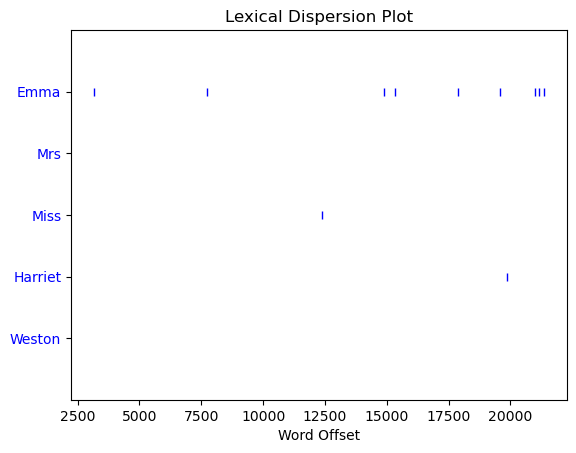

In [110]:

emma_text.dispersion_plot(list(names.index))